# Main




---

# 00 Setup


# 0. Setup


In [30]:
from pathlib import Path
import os
import sys
import shutil
import subprocess
import zipfile
import json

REPO_NAME = 'ML-Tubes-2_RecursiveLearnaholic'
REPO_URL = 'https://github.com/Rusmn/ML-Tubes-2_RecursiveLearnaholic.git'
BRANCH = None
GPU_REQUIRED = None
USE_SYMLINK = True
DOWNLOAD_DATA = True

KAGGLE_WORK = Path('/kaggle/working')
KAGGLE_INPUT = Path('/kaggle/input')
COLAB_WORK = Path('/content')


def detect_platform():
    if KAGGLE_WORK.exists():
        return 'kaggle', KAGGLE_WORK, KAGGLE_INPUT
    if COLAB_WORK.exists():
        return 'colab', COLAB_WORK, COLAB_WORK
    return 'local', Path.cwd().resolve(), Path.cwd().resolve()


def find_root(start=None):
    start = Path(start or Path.cwd()).resolve()
    for path in [start] + list(start.parents):
        if (path / 'src').exists() and (path / 'data').exists():
            return path
    return None

PLATFORM, WORK_DIR, INPUT_DIR = detect_platform()
if GPU_REQUIRED is None:
    GPU_REQUIRED = PLATFORM in {'kaggle', 'colab'}
ROOT = find_root()
if ROOT is None and PLATFORM in {'kaggle', 'colab'}:
    ROOT = WORK_DIR / REPO_NAME
    if not (ROOT / 'src').exists():
        cmd = ['git', 'clone', '--depth', '1']
        if BRANCH:
            cmd += ['--branch', BRANCH]
        cmd += [REPO_URL, str(ROOT)]
        subprocess.run(cmd, check=True)
elif ROOT is None:
    raise RuntimeError('Repo root tidak ditemukan')

ROOT = ROOT.resolve()
SRC = ROOT / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

print('platform:', PLATFORM)
print('root:', ROOT)
print('input:', INPUT_DIR)

platform: local
root: /Users/rusmn/Kuliah/SEMESTER 6/Machine Learning/Tubes2/ML-Tubes-2_RecursiveLearnaholic
input: /Users/rusmn/Kuliah/SEMESTER 6/Machine Learning/Tubes2/ML-Tubes-2_RecursiveLearnaholic/notebooks


In [31]:
import importlib

required = ['numpy', 'pandas', 'matplotlib', 'tensorflow', 'sklearn', 'PIL']
missing = []
for package in required:
    try:
        importlib.import_module('PIL' if package == 'PIL' else package)
        print(package, 'ok')
    except Exception as exc:
        print(package, 'missing:', exc)
        missing.append(package)

if missing:
    print('Install dependency: ', missing)

numpy ok
pandas ok
matplotlib ok
tensorflow ok
sklearn ok
PIL ok


In [32]:
try:
    import tensorflow as tf
    gpus = tf.config.list_physical_devices('GPU')
    for gpu in gpus:
        try:
            tf.config.experimental.set_memory_growth(gpu, True)
        except Exception:
            pass
    print('GPU:', gpus)
    if GPU_REQUIRED and not gpus:
        raise RuntimeError('GPU tidak terdeteksi.')
except ImportError:
    if GPU_REQUIRED:
        raise
    print('TensorFlow belum tersedia.')

GPU: []


## Data Setup

In [33]:
IMAGE_EXTS = {'.jpg', '.jpeg', '.png'}
INTEL_CLASSES = {'buildings', 'forest', 'glacier', 'mountain', 'sea', 'street'}


def count_images(path):
    path = Path(path)
    if not path.exists():
        return 0
    return sum(1 for item in path.rglob('*') if item.suffix.lower() in IMAGE_EXTS)


def class_dirs(path):
    path = Path(path)
    if not path.exists():
        return set()
    return {item.name for item in path.iterdir() if item.is_dir()}


def find_intel(search_root):
    search_root = Path(search_root)
    if not search_root.exists():
        return None, None
    candidates = []
    for path in search_root.rglob('*'):
        if not path.is_dir() or path.name.lower() not in {'seg_train', 'seg_test'}:
            continue
        nested = path / path.name
        if INTEL_CLASSES.issubset(class_dirs(path)):
            candidates.append((path.name.lower(), path, count_images(path)))
        elif nested.exists() and INTEL_CLASSES.issubset(class_dirs(nested)):
            candidates.append((path.name.lower(), nested, count_images(nested)))
    train = sorted([item for item in candidates if item[0] == 'seg_train'], key=lambda item: -item[2])
    test = sorted([item for item in candidates if item[0] == 'seg_test'], key=lambda item: -item[2])
    return (train[0][1] if train else None), (test[0][1] if test else None)


def find_flickr(search_root):
    search_root = Path(search_root)
    if not search_root.exists():
        return None, None
    image_dirs = []
    captions = []
    for path in search_root.rglob('*'):
        if path.is_file() and path.name.lower() in {'captions.txt', 'flickr8k.token.txt'}:
            captions.append(path)
        elif path.is_dir() and path.name.lower() in {'images', 'flicker8k_dataset', 'flickr8k_dataset'}:
            total = count_images(path)
            if total > 1000:
                image_dirs.append((path, total))
    image_dirs = sorted(image_dirs, key=lambda item: -item[1])
    captions = sorted(captions, key=lambda path: (path.name.lower() != 'captions.txt', len(str(path))))
    return (image_dirs[0][0] if image_dirs else None), (captions[0] if captions else None)


def extract_zips(search_root, extract_root):
    search_root = Path(search_root)
    extract_root = Path(extract_root)
    extract_root.mkdir(parents=True, exist_ok=True)
    if not search_root.exists():
        return []
    outputs = []
    for zip_path in search_root.rglob('*.zip'):
        name = zip_path.name.lower()
        if not any(key in name for key in ['intel', 'seg', 'flickr', 'flicker', 'caption']):
            continue
        target = extract_root / zip_path.stem
        marker = extract_root / f'{zip_path.stem}.done'
        if not marker.exists():
            target.mkdir(parents=True, exist_ok=True)
            with zipfile.ZipFile(zip_path) as archive:
                archive.extractall(target)
            marker.write_text('done', encoding='utf-8')
        outputs.append(target)
    return outputs


def download_dataset(slug, target_root):
    target_root = Path(target_root)
    target_root.mkdir(parents=True, exist_ok=True)
    target = target_root / slug.replace('/', '__')
    if target.exists():
        return target
    try:
        import kagglehub
        downloaded = Path(kagglehub.dataset_download(slug))
        try:
            os.symlink(downloaded, target, target_is_directory=True)
        except OSError:
            shutil.copytree(downloaded, target)
        return target
    except Exception:
        target.mkdir(parents=True, exist_ok=True)
        subprocess.run(['kaggle', 'datasets', 'download', '-d', slug, '-p', str(target), '--unzip'], check=True)
        return target


def place(src, dst):
    src = Path(src).resolve()
    dst = Path(dst)
    dst.parent.mkdir(parents=True, exist_ok=True)
    if dst.exists() or dst.is_symlink():
        return dst
    if USE_SYMLINK:
        try:
            os.symlink(src, dst, target_is_directory=src.is_dir())
            return dst
        except OSError:
            pass
    if src.is_dir():
        shutil.copytree(src, dst)
    else:
        shutil.copy2(src, dst)
    return dst

search_roots = [ROOT / 'data' / 'raw', INPUT_DIR]
extract_root = WORK_DIR / 'datasets_extracted'
for base in list(search_roots):
    search_roots.extend(extract_zips(base, extract_root))

intel_train = intel_test = flickr_images = flickr_captions = None
for base in search_roots:
    intel_train = intel_train or find_intel(base)[0]
    intel_test = intel_test or find_intel(base)[1]
    flickr_images = flickr_images or find_flickr(base)[0]
    flickr_captions = flickr_captions or find_flickr(base)[1]

if DOWNLOAD_DATA and (intel_train is None or intel_test is None):
    data_root = WORK_DIR / 'kaggle_datasets'
    download_dataset('puneet6060/intel-image-classification', data_root)
    intel_train = intel_train or find_intel(data_root)[0]
    intel_test = intel_test or find_intel(data_root)[1]

if DOWNLOAD_DATA and (flickr_images is None or flickr_captions is None):
    data_root = WORK_DIR / 'kaggle_datasets'
    download_dataset('adityajn105/flickr8k', data_root)
    flickr_images = flickr_images or find_flickr(data_root)[0]
    flickr_captions = flickr_captions or find_flickr(data_root)[1]

missing = []
if intel_train is None: missing.append('Intel train')
if intel_test is None: missing.append('Intel test')
if flickr_images is None: missing.append('Flickr images')
if flickr_captions is None: missing.append('Flickr captions')
if missing:
    raise FileNotFoundError(', '.join(missing))

paths = {
    'intel_train': str(place(intel_train, ROOT / 'data/raw/intel/seg_train')),
    'intel_test': str(place(intel_test, ROOT / 'data/raw/intel/seg_test')),
    'flickr_images': str(place(flickr_images, ROOT / 'data/raw/flickr8k/Images')),
    'flickr_captions': str(place(flickr_captions, ROOT / 'data/raw/flickr8k/captions.txt')),
}
status = {
    'platform': PLATFORM,
    'root': str(ROOT),
    'paths': paths,
    'counts': {
        'intel_train': count_images(paths['intel_train']),
        'intel_test': count_images(paths['intel_test']),
        'flickr_images': count_images(paths['flickr_images']),
    },
}
status_path = ROOT / 'reports/tables/setup_status.json'
status_path.parent.mkdir(parents=True, exist_ok=True)
status_path.write_text(json.dumps(status, indent=2), encoding='utf-8')
print(json.dumps(status, indent=2))

{
  "platform": "local",
  "root": "/Users/rusmn/Kuliah/SEMESTER 6/Machine Learning/Tubes2/ML-Tubes-2_RecursiveLearnaholic",
  "paths": {
    "intel_train": "/Users/rusmn/Kuliah/SEMESTER 6/Machine Learning/Tubes2/ML-Tubes-2_RecursiveLearnaholic/data/raw/intel/seg_train",
    "intel_test": "/Users/rusmn/Kuliah/SEMESTER 6/Machine Learning/Tubes2/ML-Tubes-2_RecursiveLearnaholic/data/raw/intel/seg_test",
    "flickr_images": "/Users/rusmn/Kuliah/SEMESTER 6/Machine Learning/Tubes2/ML-Tubes-2_RecursiveLearnaholic/data/raw/flickr8k/Images",
    "flickr_captions": "/Users/rusmn/Kuliah/SEMESTER 6/Machine Learning/Tubes2/ML-Tubes-2_RecursiveLearnaholic/data/raw/flickr8k/captions.txt"
  },
  "counts": {
    "intel_train": 14034,
    "intel_test": 3000,
    "flickr_images": 8091
  }
}


---

# 01 Cnn


# 1. Cnn

In [34]:
from pathlib import Path
import sys

def find_root(start=None):
    start = Path(start or Path.cwd()).resolve()
    for path in [start] + list(start.parents):
        if (path / 'src').exists() and (path / 'data').exists():
            return path
    raise RuntimeError('Repo root tidak ditemukan.')

ROOT = find_root()
SRC = ROOT / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))
print('ROOT:', ROOT)

ROOT: /Users/rusmn/Kuliah/SEMESTER 6/Machine Learning/Tubes2/ML-Tubes-2_RecursiveLearnaholic


In [35]:
import itertools
import json
import pickle
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models

from cnn.layers import Conv2D, LocallyConnected2D, MaxPooling2D, AveragePooling2D, Flatten, Dense, Sequential

SEED = 42
IMAGE_SIZE = (150, 150)
CNN_BATCH = 32
CNN_EPOCHS = 5
USE_EXISTING_CNN = True
SKIP_CNN_TRAINING = True
REBUILD_CNN_SCRATCH = False
RUN_FULL_NON_SHARED = False
NON_SHARED_SAMPLE_PER_CLASS = 1

CNN_MODEL_DIR = ROOT / 'models' / 'cnn'
TABLE_DIR = ROOT / 'reports' / 'tables'
FIG_DIR = ROOT / 'reports' / 'figures'
for folder in [CNN_MODEL_DIR, TABLE_DIR, FIG_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

TRAIN_DIR = ROOT / 'data/raw/intel/seg_train'
TEST_DIR = ROOT / 'data/raw/intel/seg_test'
CLASSES = ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
CLASS_TO_ID = {name: idx for idx, name in enumerate(CLASSES)}


In [36]:
def load_intel_dataset(root, target_size=(150, 150)):
    images = []
    labels = []
    for class_name in CLASSES:
        class_dir = Path(root) / class_name
        for path in sorted(class_dir.glob('*.jpg')):
            img = Image.open(path).convert('RGB').resize(target_size)
            images.append(np.asarray(img, dtype='float32') / 255.0)
            labels.append(CLASS_TO_ID[class_name])
    return np.asarray(images, dtype='float32'), np.asarray(labels, dtype='int64')

X_train_full, y_train_full = load_intel_dataset(TRAIN_DIR, IMAGE_SIZE)
X_test, y_test = load_intel_dataset(TEST_DIR, IMAGE_SIZE)
if len(X_train_full) == 0 or len(X_test) == 0:
    raise RuntimeError('Dataset Intel belum siap. Run Setup lebih dulu.')
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=SEED, stratify=y_train_full
)
print('train:', X_train.shape, 'val:', X_val.shape, 'test:', X_test.shape)

train: (11227, 150, 150, 3) val: (2807, 150, 150, 3) test: (3000, 150, 150, 3)


In [38]:
def make_cnn_model(num_layers, filters, kernel_size, pooling):
    pool_layer = layers.MaxPooling2D if pooling == 'max' else layers.AveragePooling2D
    model_layers = [layers.Input(shape=(*IMAGE_SIZE, 3))]
    for index in range(num_layers):
        model_layers.append(layers.Conv2D(filters, kernel_size, padding='same', activation='relu'))
        if index == 0 or index == num_layers - 1:
            model_layers.append(pool_layer(pool_size=(2, 2)))
    model_layers.extend([layers.Flatten(), layers.Dense(len(CLASSES), activation='softmax')])
    model = models.Sequential(model_layers)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model


def normalize_cnn_records(df):
    if df.empty:
        return df
    rename = {
        'experiment_id': 'experiment',
        'pooling_type': 'pooling',
        'keras_weight_path': 'weights_path',
    }
    df = df.rename(columns={old: new for old, new in rename.items() if old in df.columns})
    if 'experiment' not in df.columns and 'index' in df.columns:
        df['experiment'] = df['index'].astype(int) - 1
    for exp_id in range(16):
        mask = df.get('experiment', pd.Series(dtype=int)).astype(int) == exp_id if 'experiment' in df.columns else []
        if len(df) and np.any(mask):
            row_index = df.index[mask][0]
            if 'weights_path' not in df.columns or pd.isna(df.loc[row_index].get('weights_path', np.nan)):
                df.loc[row_index, 'weights_path'] = str(CNN_MODEL_DIR / f'keras_weights_exp_{exp_id}.npy')
            if 'history_path' not in df.columns or pd.isna(df.loc[row_index].get('history_path', np.nan)):
                df.loc[row_index, 'history_path'] = str(CNN_MODEL_DIR / f'history_exp_{exp_id}.pkl')
    return df

configs = []
for num_layers, filters, kernel_size, pooling in itertools.product([2, 3], [32, 64], [3, 5], ['max', 'avg']):
    configs.append({'num_layers': num_layers, 'filters': filters, 'kernel_size': kernel_size, 'pooling': pooling})

record_path = TABLE_DIR / 'cnn_records.csv'
existing_df = normalize_cnn_records(pd.read_csv(record_path)) if record_path.exists() else pd.DataFrame()
records = existing_df.to_dict('records') if not existing_df.empty else []
seen = {int(row['experiment']) for row in records if 'experiment' in row}

def cnn_artifacts_complete():
    if len(seen) < 16:
        return False
    for exp_id in range(16):
        if not (CNN_MODEL_DIR / f'keras_weights_exp_{exp_id}.npy').exists():
            return False
        if not (CNN_MODEL_DIR / f'history_exp_{exp_id}.pkl').exists():
            return False
    return True

if SKIP_CNN_TRAINING and cnn_artifacts_complete():
    print('CNN training skipped; using existing 16 experiments.')
elif SKIP_CNN_TRAINING:
    raise RuntimeError('CNN artifacts are incomplete but SKIP_CNN_TRAINING=True.')
else:
    train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)).shuffle(len(X_train), seed=SEED).batch(CNN_BATCH).prefetch(tf.data.AUTOTUNE)
    val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val)).batch(CNN_BATCH).prefetch(tf.data.AUTOTUNE)
    test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(CNN_BATCH).prefetch(tf.data.AUTOTUNE)
    for exp_id, cfg in enumerate(configs):
        weight_path = CNN_MODEL_DIR / f'keras_weights_exp_{exp_id}.npy'
        history_path = CNN_MODEL_DIR / f'history_exp_{exp_id}.pkl'
        if exp_id in seen and weight_path.exists() and history_path.exists():
            print('skip cnn exp', exp_id)
            continue
        print('training cnn exp', exp_id, cfg)
        tf.keras.backend.clear_session()
        model = make_cnn_model(**cfg)
        t0 = time.time()
        history = model.fit(train_ds, validation_data=val_ds, epochs=CNN_EPOCHS, verbose=1)
        elapsed = time.time() - t0
        preds = np.argmax(model.predict(test_ds, verbose=0), axis=1)[:len(y_test)]
        f1 = f1_score(y_test, preds, average='macro')
        np.save(weight_path, np.array(model.get_weights(), dtype=object), allow_pickle=True)
        with open(history_path, 'wb') as file:
            pickle.dump(history.history, file)
        records.append({
            'experiment': exp_id,
            **cfg,
            'macro_f1': float(f1),
            'runtime_seconds': float(elapsed),
            'weights_path': str(weight_path),
            'history_path': str(history_path),
        })
        pd.DataFrame(records).sort_values('experiment').to_csv(record_path, index=False)

cnn_df = normalize_cnn_records(pd.DataFrame(records)).sort_values('macro_f1', ascending=False)
cnn_df.to_csv(record_path, index=False)
cnn_df


CNN training skipped; using existing 16 experiments.


,index,experiment,num_layers,filters,kernel_size,pooling,macro_f1,model_path,weights_path,history_path,shared_parameters
0,13,12,3,64,3,max,0.760607,/Users/rusmn/Kuliah/SEMESTER 6/Machine Learnin...,/Users/rusmn/Kuliah/SEMESTER 6/Machine Learnin...,/Users/rusmn/Kuliah/SEMESTER 6/Machine Learnin...,True
1,9,8,3,32,3,max,0.743906,/Users/rusmn/Kuliah/SEMESTER 6/Machine Learnin...,/Users/rusmn/Kuliah/SEMESTER 6/Machine Learnin...,/Users/rusmn/Kuliah/SEMESTER 6/Machine Learnin...,True
2,15,14,3,64,5,max,0.741806,/Users/rusmn/Kuliah/SEMESTER 6/Machine Learnin...,/Users/rusmn/Kuliah/SEMESTER 6/Machine Learnin...,/Users/rusmn/Kuliah/SEMESTER 6/Machine Learnin...,True
3,2,1,2,32,3,avg,0.737065,/Users/rusmn/Kuliah/SEMESTER 6/Machine Learnin...,/Users/rusmn/Kuliah/SEMESTER 6/Machine Learnin...,/Users/rusmn/Kuliah/SEMESTER 6/Machine Learnin...,True
4,14,13,3,64,3,avg,0.735633,/Users/rusmn/Kuliah/SEMESTER 6/Machine Learnin...,/Users/rusmn/Kuliah/SEMESTER 6/Machine Learnin...,/Users/rusmn/Kuliah/SEMESTER 6/Machine Learnin...,True
5,12,11,3,32,5,avg,0.734018,/Users/rusmn/Kuliah/SEMESTER 6/Machine Learnin...,/Users/rusmn/Kuliah/SEMESTER 6/Machine Learnin...,/Users/rusmn/Kuliah/SEMESTER 6/Machine Learnin...,True
6,16,15,3,64,5,avg,0.733605,/Users/rusmn/Kuliah/SEMESTER 6/Machine Learnin...,/Users/rusmn/Kuliah/SEMESTER 6/Machine Learnin...,/Users/rusmn/Kuliah/SEMESTER 6/Machine Learnin...,True
7,11,10,3,32,5,max,0.723266,/Users/rusmn/Kuliah/SEMESTER 6/Machine Learnin...,/Users/rusmn/Kuliah/SEMESTER 6/Machine Learnin...,/Users/rusmn/Kuliah/SEMESTER 6/Machine Learnin...,True
8,10,9,3,32,3,avg,0.722801,/Users/rusmn/Kuliah/SEMESTER 6/Machine Learnin...,/Users/rusmn/Kuliah/SEMESTER 6/Machine Learnin...,/Users/rusmn/Kuliah/SEMESTER 6/Machine Learnin...,True
9,6,5,2,64,3,avg,0.712394,/Users/rusmn/Kuliah/SEMESTER 6/Machine Learnin...,/Users/rusmn/Kuliah/SEMESTER 6/Machine Learnin...,/Users/rusmn/Kuliah/SEMESTER 6/Machine Learnin...,True


In [39]:
cnn_df = normalize_cnn_records(pd.read_csv(TABLE_DIR / 'cnn_records.csv'))
best = cnn_df.sort_values('macro_f1', ascending=False).iloc[0]
best_exp = int(best['experiment'])
best_cfg = {
    'num_layers': int(best['num_layers']),
    'filters': int(best['filters']),
    'kernel_size': int(best['kernel_size']),
    'pooling': str(best['pooling']),
}
print('best:', best_exp, best_cfg)

manual_path = TABLE_DIR / 'cnn_manual_comparison.csv'
if USE_EXISTING_CNN and manual_path.exists() and not REBUILD_CNN_SCRATCH:
    manual = pd.read_csv(manual_path)
    print('CNN scratch comparison loaded from existing artifact.')
else:
    best_model = make_cnn_model(**best_cfg)
    best_weights = np.load(CNN_MODEL_DIR / f'keras_weights_exp_{best_exp}.npy', allow_pickle=True)
    best_model.set_weights(list(best_weights))

    sample_idx = []
    per_class = None if RUN_FULL_NON_SHARED else NON_SHARED_SAMPLE_PER_CLASS
    for label in sorted(np.unique(y_test)):
        candidates = np.flatnonzero(y_test == label)
        sample_idx.extend(candidates.tolist() if per_class is None else candidates[:per_class].tolist())
    X_sample = X_test[sample_idx]
    y_sample = y_test[sample_idx]
    keras_pred = np.argmax(best_model.predict(X_sample, verbose=0), axis=1)

    scratch_layers = []
    weight_iter = iter(best_model.get_weights())
    for layer in best_model.layers:
        if isinstance(layer, tf.keras.layers.Conv2D):
            kernel = next(weight_iter); bias = next(weight_iter)
            conv = Conv2D(filters=kernel.shape[-1], kernel_size=kernel.shape[:2], padding=kernel.shape[0] // 2, activation='relu')
            conv.load_keras([kernel, bias])
            scratch_layers.append(conv)
        elif isinstance(layer, tf.keras.layers.MaxPooling2D):
            scratch_layers.append(MaxPooling2D(pool_size=(2, 2), strides=2))
        elif isinstance(layer, tf.keras.layers.AveragePooling2D):
            scratch_layers.append(AveragePooling2D(pool_size=(2, 2), strides=2))
        elif isinstance(layer, tf.keras.layers.Flatten):
            scratch_layers.append(Flatten())
        elif isinstance(layer, tf.keras.layers.Dense):
            kernel = next(weight_iter); bias = next(weight_iter)
            dense = Dense(activation='softmax')
            dense.load_keras([kernel, bias])
            scratch_layers.append(dense)

    t0 = time.time()
    scratch_model = Sequential(scratch_layers)
    scratch_pred = np.argmax(scratch_model.forward(X_sample), axis=1)
    scratch_seconds = time.time() - t0
    shared_params = scratch_model.count_params()

    h, w, channels = IMAGE_SIZE[0], IMAGE_SIZE[1], 3
    non_shared_params = 0
    for layer in best_model.layers:
        if isinstance(layer, tf.keras.layers.Conv2D):
            k_h, k_w = layer.kernel_size
            out_ch = layer.filters
            non_shared_params += h * w * ((k_h * k_w * channels * out_ch) + out_ch)
            channels = out_ch
        elif isinstance(layer, (tf.keras.layers.MaxPooling2D, tf.keras.layers.AveragePooling2D)):
            h //= 2; w //= 2
        elif isinstance(layer, tf.keras.layers.Dense):
            non_shared_params += int(np.prod(layer.kernel.shape) + np.prod(layer.bias.shape))

    manual = pd.DataFrame([
        {'implementation': 'keras_shared', 'macro_f1': f1_score(y_sample, keras_pred, average='macro'), 'runtime_seconds': np.nan, 'params': int(best_model.count_params()), 'numerical_match': True, 'shared_parameters': True},
        {'implementation': 'scratch_numpy_shared', 'macro_f1': f1_score(y_sample, scratch_pred, average='macro'), 'runtime_seconds': scratch_seconds, 'params': int(shared_params), 'numerical_match': bool(np.array_equal(keras_pred, scratch_pred)), 'shared_parameters': True},
        {'implementation': 'scratch_numpy_non_shared', 'macro_f1': np.nan, 'runtime_seconds': np.nan, 'params': int(non_shared_params), 'numerical_match': False, 'shared_parameters': False, 'macro_f1_small_batch': np.nan, 'parameter_explosion': float(non_shared_params / max(shared_params, 1))},
    ])
    manual.to_csv(manual_path, index=False)

manual


best: 12 {'num_layers': 3, 'filters': 64, 'kernel_size': 3, 'pooling': 'max'}
CNN scratch comparison loaded from existing artifact.


,implementation,macro_f1,runtime_seconds,params,numerical_match,config,macro_f1_small_batch,shared_params,parameter_explosion,shared_parameters
0,keras_shared,0.756794,0.945887,601350,True,NaN,NaN,NaN,NaN,NaN
1,scratch_numpy_shared,0.756794,8.373747,601350,True,NaN,NaN,NaN,NaN,NaN
2,scratch_numpy_non_shared,NaN,NaN,1079445702,NaN,"{'num_layers': 3, 'filters': 64, 'kernel_size'...",0.25,601350.0,1795.037336,False


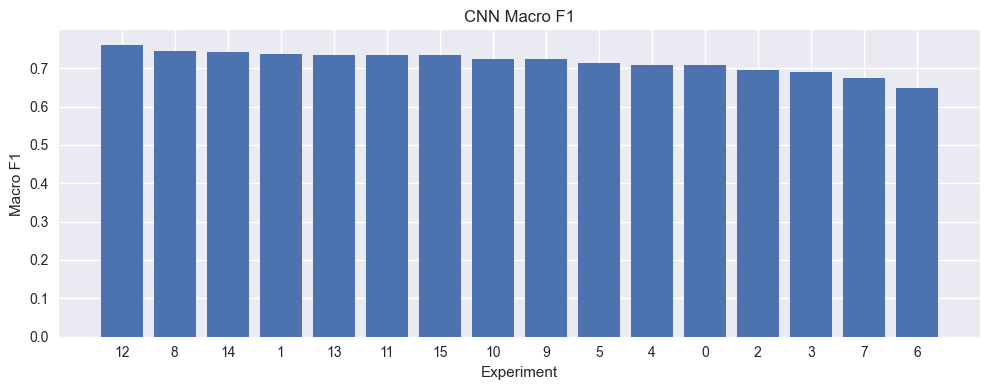

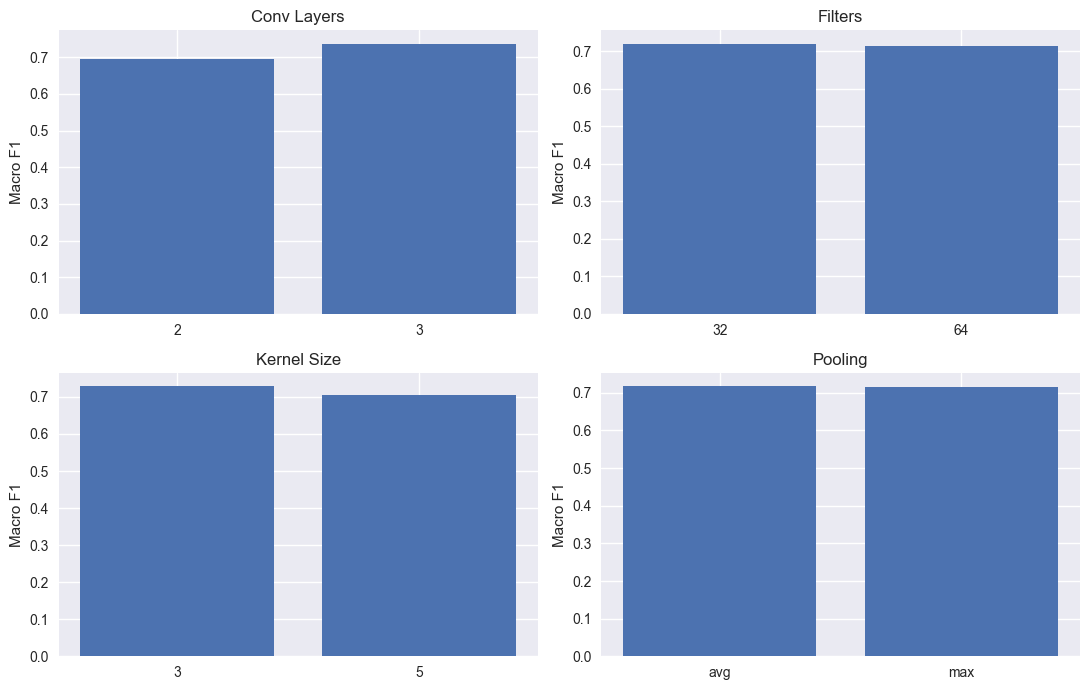

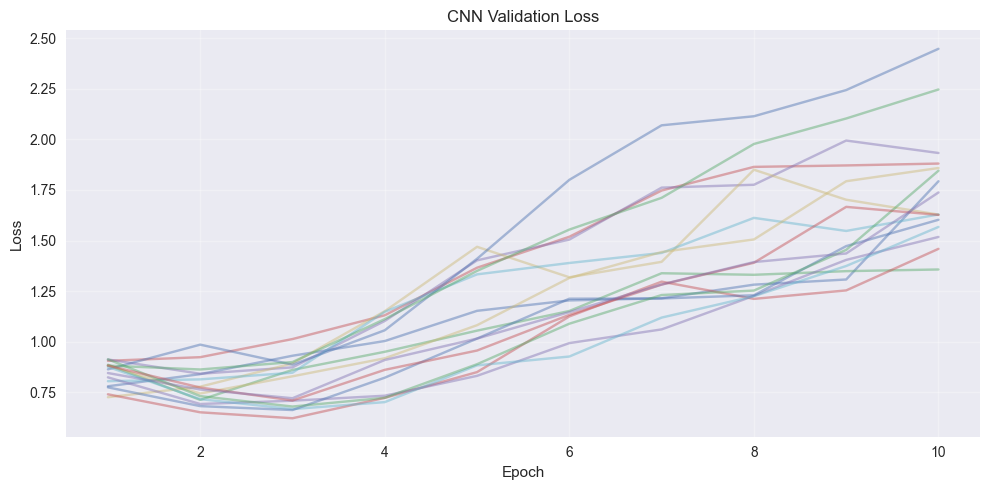

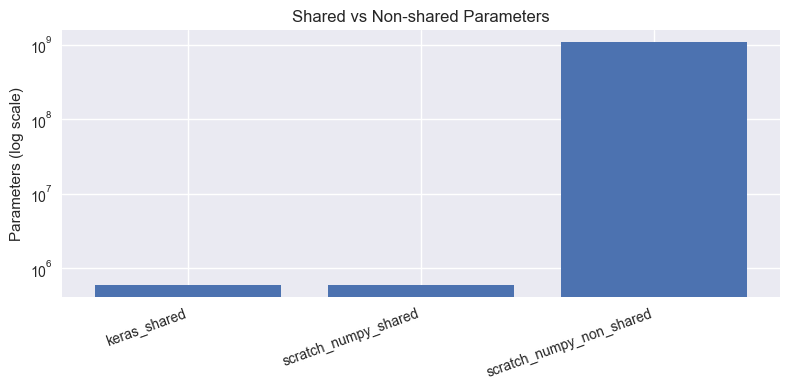

In [40]:
cnn_df = normalize_cnn_records(pd.read_csv(TABLE_DIR / 'cnn_records.csv'))
for group_col, out_name in [
    ('num_layers', 'cnn_by_num_layers.csv'),
    ('filters', 'cnn_by_filters.csv'),
    ('kernel_size', 'cnn_by_kernel_size.csv'),
    ('pooling', 'cnn_by_pooling_type.csv'),
]:
    cnn_df.groupby(group_col)[['macro_f1']].mean().reset_index().to_csv(TABLE_DIR / out_name, index=False)

plt.figure(figsize=(10, 4))
plt.bar(cnn_df['experiment'].astype(str), cnn_df['macro_f1'])
plt.xlabel('Experiment')
plt.ylabel('Macro F1')
plt.title('CNN Macro F1')
plt.tight_layout()
plt.savefig(FIG_DIR / 'cnn_macro_f1.png', dpi=150)
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for axis, (group_col, title) in zip(axes.ravel(), [('num_layers', 'Conv Layers'), ('filters', 'Filters'), ('kernel_size', 'Kernel Size'), ('pooling', 'Pooling')]):
    summary = cnn_df.groupby(group_col)['macro_f1'].mean().reset_index()
    axis.bar(summary[group_col].astype(str), summary['macro_f1'])
    axis.set_title(title)
    axis.set_ylabel('Macro F1')
fig.tight_layout()
fig.savefig(FIG_DIR / 'cnn_hyperparameters.png', dpi=150)
plt.show()

loss_rows = []
for row in cnn_df.itertuples():
    history_path = Path(getattr(row, 'history_path'))
    if not history_path.is_absolute():
        history_path = ROOT / history_path
    if not history_path.exists():
        continue
    with open(history_path, 'rb') as file:
        history = pickle.load(file)
    for epoch, (loss, val_loss) in enumerate(zip(history.get('loss', []), history.get('val_loss', [])), start=1):
        loss_rows.append({'experiment': int(row.experiment), 'epoch': epoch, 'loss': loss, 'val_loss': val_loss})
loss_df = pd.DataFrame(loss_rows)
if not loss_df.empty:
    plt.figure(figsize=(10, 5))
    for exp_id, part in loss_df.groupby('experiment'):
        plt.plot(part['epoch'], part['val_loss'], alpha=0.45, label=str(exp_id))
    plt.title('CNN Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'cnn_validation_loss.png', dpi=150)
    plt.show()

manual = pd.read_csv(TABLE_DIR / 'cnn_manual_comparison.csv')
if {'implementation', 'params'}.issubset(manual.columns):
    plt.figure(figsize=(8, 4))
    plt.bar(manual['implementation'], pd.to_numeric(manual['params'], errors='coerce'))
    plt.yscale('log')
    plt.xticks(rotation=20, ha='right')
    plt.ylabel('Parameters (log scale)')
    plt.title('Shared vs Non-shared Parameters')
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'cnn_shared_parameters.png', dpi=150)
    plt.show()


---

# 02 Caption


# 2. Caption


In [41]:
from pathlib import Path
import sys

def find_root(start=None):
    start = Path(start or Path.cwd()).resolve()
    for path in [start] + list(start.parents):
        if (path / 'src').exists() and (path / 'data').exists():
            return path
    raise RuntimeError('Repo root tidak ditemukan.')

ROOT = find_root()
SRC = ROOT / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))
print('ROOT:', ROOT)


ROOT: /Users/rusmn/Kuliah/SEMESTER 6/Machine Learning/Tubes2/ML-Tubes-2_RecursiveLearnaholic


In [43]:
import json
import re
from collections import defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import tensorflow as tf

from cnn.utility import image_paths, feature_extractor
from rnn.preprocess import clean_text, tokenize, make_vocab, pad_seq

SEED = 42
MAX_SEQUENCE_LENGTH = 34
MIN_WORD_FREQ = 1
FEATURE_BATCH = 64
IMAGE_SIZE = (299, 299)
TRAIN_RATIO = 0.75
VAL_RATIO = 0.125
USE_KAGGLE_RNN_ARTIFACTS = True
REBUILD_PROCESSED = False

RAW_DIR = ROOT / 'data/raw/flickr8k'
IMAGE_DIR = RAW_DIR / 'Images'
CAPTION_PATH = RAW_DIR / 'captions.txt'
FEATURE_DIR = ROOT / 'data/features'
PROC_DIR = ROOT / 'data/processed/flickr8k'
TABLE_DIR = ROOT / 'reports/tables'
for folder in [FEATURE_DIR, PROC_DIR, TABLE_DIR]:
    folder.mkdir(parents=True, exist_ok=True)


In [44]:
def parse_captions(path):
    by_image = defaultdict(list)
    with Path(path).open('r', encoding='utf-8') as file:
        for raw in file:
            line = raw.strip()
            if not line:
                continue
            if ',' in line:
                image_raw, caption = line.split(',', 1)
            elif '	' in line:
                image_raw, caption = line.split('	', 1)
            else:
                continue
            image_id = Path(image_raw.split('#')[0]).name
            if image_id.lower() in {'image', 'filename'}:
                continue
            caption = clean_text(caption)
            if caption:
                by_image[image_id].append(caption)
    return dict(by_image)

caption_by_image = parse_captions(CAPTION_PATH)
print('caption images:', len(caption_by_image))
print('captions:', sum(len(v) for v in caption_by_image.values()))


caption images: 8091
captions: 40455


In [45]:
feature_path = FEATURE_DIR / 'flickr8k_features.npy'
feature_id_path = FEATURE_DIR / 'flickr8k_image_ids.txt'
encoder_path = ROOT / 'models/cnn/flickr8k_inceptionv3_encoder.keras'
encoder_path.parent.mkdir(parents=True, exist_ok=True)

if feature_path.exists() and feature_id_path.exists():
    features = np.load(feature_path)
    feature_ids = [line.strip() for line in feature_id_path.read_text(encoding='utf-8').splitlines() if line.strip()]
    print('skip feature extraction:', features.shape)
else:
    paths = image_paths(IMAGE_DIR)
    cached_weights = Path.home() / '.keras/models/inception_v3_weights_tf_dim_ordering_tf_kernels_notop.h5'
    weights_arg = str(cached_weights) if cached_weights.exists() else 'imagenet'
    encoder = tf.keras.applications.InceptionV3(include_top=False, weights=weights_arg, pooling='avg')
    encoder.trainable = False
    encoder.save(encoder_path)
    features = feature_extractor(
        paths,
        encoder,
        feature_path,
        target_size=IMAGE_SIZE,
        batch_size=FEATURE_BATCH,
        image_id_path=feature_id_path,
        preprocess_fn=tf.keras.applications.inception_v3.preprocess_input,
    )
    feature_ids = [line.strip() for line in feature_id_path.read_text(encoding='utf-8').splitlines() if line.strip()]
    print('saved:', features.shape)

# Older feature files may store stems. Normalize to filenames when possible.
if feature_ids and not feature_ids[0].lower().endswith(('.jpg', '.jpeg', '.png')):
    image_name_lookup = {Path(path).stem: Path(path).name for path in image_paths(IMAGE_DIR)}
    feature_ids = [image_name_lookup.get(image_id, image_id) for image_id in feature_ids]
    feature_id_path.write_text('\n'.join(feature_ids), encoding='utf-8')
    print('normalized feature ids to filenames')


skip feature extraction: (8091, 2048)
normalized feature ids to filenames


In [46]:
feature_ids = [line.strip() for line in feature_id_path.read_text(encoding='utf-8').splitlines() if line.strip()]
features = np.load(feature_path).astype('float32')
valid_ids = sorted(set(feature_ids).intersection(caption_by_image))
split_path = PROC_DIR / 'split.json'

if USE_KAGGLE_RNN_ARTIFACTS and split_path.exists():
    split = json.loads(split_path.read_text(encoding='utf-8'))
    print('using existing image-level split:', {key: len(value) for key, value in split.items()})
else:
    rng = np.random.default_rng(SEED)
    order = np.array(valid_ids, dtype=object)
    rng.shuffle(order)
    n_train = int(round(len(order) * TRAIN_RATIO))
    n_val = int(round(len(order) * VAL_RATIO))
    split = {
        'train': order[:n_train].tolist(),
        'val': order[n_train:n_train+n_val].tolist(),
        'test': order[n_train+n_val:].tolist(),
    }
    split_path.write_text(json.dumps(split, indent=2), encoding='utf-8')
    print('created split:', {key: len(value) for key, value in split.items()})


using existing image-level split: {'test': 1012, 'train': 6068, 'val': 1011}


In [47]:
required_arrays = [PROC_DIR / f'{name}_{kind}.npy' for name in ['train', 'val', 'test'] for kind in ['features', 'captions']]
required_ids = [PROC_DIR / f'{name}_image_ids.txt' for name in ['train', 'val', 'test']]
vocab_path = PROC_DIR / 'vocab.json'

if (not REBUILD_PROCESSED) and vocab_path.exists() and all(path.exists() for path in required_arrays + required_ids):
    word_to_index = json.loads(vocab_path.read_text(encoding='utf-8'))
    summary = {
        'max_sequence_length': MAX_SEQUENCE_LENGTH,
        'vocab_size': len(word_to_index),
        'split_images': {key: len(value) for key, value in split.items()},
        'source': 'existing_processed_arrays',
    }
    print('processed caption arrays already exist')
else:
    train_captions = [caption for image_id in split['train'] for caption in caption_by_image[image_id]]
    if vocab_path.exists() and USE_KAGGLE_RNN_ARTIFACTS:
        word_to_index = json.loads(vocab_path.read_text(encoding='utf-8'))
        print('using existing train vocabulary:', len(word_to_index))
    else:
        word_to_index, _ = make_vocab(train_captions, special=['<pad>', '<start>', '<end>', '<unk>'], min_freq=MIN_WORD_FREQ)
        vocab_path.write_text(json.dumps(word_to_index, indent=2), encoding='utf-8')

    feature_lookup = {image_id: features[index] for index, image_id in enumerate(feature_ids)}

    def encode_caption(caption):
        pad_id = word_to_index['<pad>']
        ids = [word_to_index['<start>']]
        ids.extend(word_to_index.get(token, word_to_index.get('<unk>', pad_id)) for token in tokenize(caption))
        ids.append(word_to_index['<end>'])
        return pad_seq(ids, MAX_SEQUENCE_LENGTH, pad_id=pad_id)

    def build_rows(image_ids):
        row_features = []
        row_sequences = []
        row_ids = []
        missing = []
        for image_id in image_ids:
            if image_id not in feature_lookup or image_id not in caption_by_image:
                missing.append(image_id)
                continue
            for caption in caption_by_image[image_id]:
                row_features.append(feature_lookup[image_id])
                row_sequences.append(encode_caption(caption))
                row_ids.append(image_id)
        if missing:
            print('missing image ids:', len(missing))
        return np.asarray(row_features, dtype='float32'), np.asarray(row_sequences, dtype='int32'), row_ids

    for name in ['train', 'val', 'test']:
        row_features, row_sequences, row_ids = build_rows(split[name])
        np.save(PROC_DIR / f'{name}_features.npy', row_features)
        np.save(PROC_DIR / f'{name}_captions.npy', row_sequences)
        (PROC_DIR / f'{name}_image_ids.txt').write_text('\n'.join(row_ids), encoding='utf-8')
        print(name, row_features.shape, row_sequences.shape)

    summary = {
        'max_sequence_length': MAX_SEQUENCE_LENGTH,
        'vocab_size': len(word_to_index),
        'split_images': {key: len(value) for key, value in split.items()},
        'source': 'rebuilt_from_split_and_features',
    }

(TABLE_DIR / 'caption_data_summary.json').write_text(json.dumps(summary, indent=2), encoding='utf-8')
summary


processed caption arrays already exist


{'max_sequence_length': 34,
 'vocab_size': 7793,
 'split_images': {'test': 1012, 'train': 6068, 'val': 1011},
 'source': 'existing_processed_arrays'}

---

# 03 Decoder


# 3. Decoder

In [48]:
from pathlib import Path
import sys

def find_root(start=None):
    start = Path(start or Path.cwd()).resolve()
    for path in [start] + list(start.parents):
        if (path / 'src').exists() and (path / 'data').exists():
            return path
    raise RuntimeError('Repo root tidak ditemukan. Jalankan dari repo, Colab, atau Kaggle working directory yang sudah berisi repo.')

ROOT = find_root()
SRC = ROOT / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))
print('ROOT:', ROOT)


ROOT: /Users/rusmn/Kuliah/SEMESTER 6/Machine Learning/Tubes2/ML-Tubes-2_RecursiveLearnaholic


In [49]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import tensorflow as tf

from rnn.sequences import teacher_pairs
from rnn.keras_models import build_preinject, compile_model
from rnn.train import grid_cfg
from rnn.weights import export_weights

SEED = 42
BATCH_SIZE = 128
EPOCHS = 10
EMBED_DIM = 256
LEARNING_RATE = 1e-3
SKIP_RNN_TRAINING = True

PROC_DIR = ROOT / 'data/processed/flickr8k'
MODEL_DIR = ROOT / 'models/rnn'
TABLE_DIR = ROOT / 'reports/tables/rnn'
for folder in [MODEL_DIR, TABLE_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

tf.keras.utils.set_random_seed(SEED)
print('SKIP_RNN_TRAINING:', SKIP_RNN_TRAINING)


SKIP_RNN_TRAINING: True


In [51]:
def repo_relative(path):
    path = Path(path)
    try:
        return path.resolve().relative_to(ROOT.resolve()).as_posix()
    except Exception:
        return path.as_posix()

def artifact_path(value):
    path = Path(str(value))
    return path if path.is_absolute() else ROOT / path

def load_existing_records():
    path = TABLE_DIR / 'train_records.json'
    if not path.exists():
        return []
    records = json.loads(path.read_text(encoding='utf-8'))
    for record in records:
        record['model_path'] = repo_relative(artifact_path(record['model_path']))
        record['weight_path'] = repo_relative(artifact_path(record['weight_path']))
        record['history_path'] = repo_relative(artifact_path(record['history_path']))
    return records

def decoder_artifacts_complete(records):
    if len(records) != 12:
        return False
    for record in records:
        if not artifact_path(record['model_path']).exists():
            return False
        if not artifact_path(record['weight_path']).exists():
            return False
        if not artifact_path(record['history_path']).exists():
            return False
    return True

records = load_existing_records()
print('existing records:', len(records), 'complete:', decoder_artifacts_complete(records))
pd.DataFrame(records)


existing records: 12 complete: True


,config,history_path,model_path,skipped_existing,weight_path
0,"{'batch_size': 128, 'caption_length': 33, 'emb...",reports/tables/rnn/rnn_layers1_hidden128_len33...,models/rnn/rnn_layers1_hidden128_len33.keras,False,models/rnn/rnn_layers1_hidden128_len33.npz
1,"{'batch_size': 128, 'caption_length': 33, 'emb...",reports/tables/rnn/rnn_layers1_hidden512_len33...,models/rnn/rnn_layers1_hidden512_len33.keras,False,models/rnn/rnn_layers1_hidden512_len33.npz
2,"{'batch_size': 128, 'caption_length': 33, 'emb...",reports/tables/rnn/rnn_layers2_hidden128_len33...,models/rnn/rnn_layers2_hidden128_len33.keras,False,models/rnn/rnn_layers2_hidden128_len33.npz
3,"{'batch_size': 128, 'caption_length': 33, 'emb...",reports/tables/rnn/rnn_layers2_hidden512_len33...,models/rnn/rnn_layers2_hidden512_len33.keras,False,models/rnn/rnn_layers2_hidden512_len33.npz
4,"{'batch_size': 128, 'caption_length': 33, 'emb...",reports/tables/rnn/rnn_layers3_hidden128_len33...,models/rnn/rnn_layers3_hidden128_len33.keras,False,models/rnn/rnn_layers3_hidden128_len33.npz
5,"{'batch_size': 128, 'caption_length': 33, 'emb...",reports/tables/rnn/rnn_layers3_hidden512_len33...,models/rnn/rnn_layers3_hidden512_len33.keras,False,models/rnn/rnn_layers3_hidden512_len33.npz
6,"{'batch_size': 128, 'caption_length': 33, 'emb...",reports/tables/rnn/lstm_layers1_hidden128_len3...,models/rnn/lstm_layers1_hidden128_len33.keras,False,models/rnn/lstm_layers1_hidden128_len33.npz
7,"{'batch_size': 128, 'caption_length': 33, 'emb...",reports/tables/rnn/lstm_layers1_hidden512_len3...,models/rnn/lstm_layers1_hidden512_len33.keras,False,models/rnn/lstm_layers1_hidden512_len33.npz
8,"{'batch_size': 128, 'caption_length': 33, 'emb...",reports/tables/rnn/lstm_layers2_hidden128_len3...,models/rnn/lstm_layers2_hidden128_len33.keras,False,models/rnn/lstm_layers2_hidden128_len33.npz
9,"{'batch_size': 128, 'caption_length': 33, 'emb...",reports/tables/rnn/lstm_layers2_hidden512_len3...,models/rnn/lstm_layers2_hidden512_len33.keras,False,models/rnn/lstm_layers2_hidden512_len33.npz


In [53]:
if SKIP_RNN_TRAINING:
    if not decoder_artifacts_complete(records):
        missing = []
        for record in records:
            for key in ['model_path', 'weight_path', 'history_path']:
                if not artifact_path(record[key]).exists():
                    missing.append(record[key])
        raise RuntimeError('SKIP_RNN_TRAINING=True tetapi artefak decoder belum lengkap. Missing: ' + ', '.join(missing[:10]))
    print('Training dilewati.')
else:
    train_features = np.load(PROC_DIR / 'train_features.npy').astype('float32')
    train_captions = np.load(PROC_DIR / 'train_captions.npy').astype('int32')
    val_features = np.load(PROC_DIR / 'val_features.npy').astype('float32')
    val_captions = np.load(PROC_DIR / 'val_captions.npy').astype('int32')
    word_to_index = json.loads((PROC_DIR / 'vocab.json').read_text(encoding='utf-8'))

    def make_dataset(features, captions, shuffle=False):
        inputs, targets = teacher_pairs(captions)
        ds = tf.data.Dataset.from_tensor_slices(((features, inputs), targets))
        if shuffle:
            ds = ds.shuffle(min(len(captions), 10000), seed=SEED, reshuffle_each_iteration=True)
        return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

    def history_dict(history):
        return {key: [float(value) for value in values] for key, values in history.history.items()}

    train_ds = make_dataset(train_features, train_captions, shuffle=True)
    val_ds = make_dataset(val_features, val_captions, shuffle=False)
    base_config = {
        'vocab_size': len(word_to_index),
        'feature_dim': int(train_features.shape[1]),
        'max_length': int(train_captions.shape[1]),
        'caption_length': int(train_captions.shape[1] - 1),
        'embed_dim': EMBED_DIM,
        'learning_rate': LEARNING_RATE,
        'batch_size': BATCH_SIZE,
        'epochs': EPOCHS,
    }

    records = []
    for cfg in grid_cfg(base_config):
        stem = Path(cfg['model_name']).stem
        model_path = MODEL_DIR / cfg['model_name']
        weight_path = MODEL_DIR / f'{stem}.npz'
        history_path = TABLE_DIR / f'{stem}_history.json'
        record = {
            'config': cfg,
            'model_path': repo_relative(model_path),
            'weight_path': repo_relative(weight_path),
            'history_path': repo_relative(history_path),
        }
        if model_path.exists() and weight_path.exists() and history_path.exists():
            print('skip decoder', cfg['model_name'])
            record['skipped_existing'] = True
            records.append(record)
            continue
        print('train decoder', cfg['model_name'])
        tf.keras.backend.clear_session()
        model = build_preinject(
            vocab_size=cfg['vocab_size'], feature_dim=cfg['feature_dim'], max_length=cfg['caption_length'],
            embed_dim=cfg['embed_dim'], hidden_size=cfg['hidden_size'], recur_layers=cfg['recur_layers'], recur_type=cfg['recur_type']
        )
        model = compile_model(model, learn_rate=cfg['learning_rate'])
        history = model.fit(train_ds, validation_data=val_ds, epochs=cfg['epochs'], verbose=1)
        model.save(model_path)
        export_weights(model, weight_path)
        history_path.write_text(json.dumps(history_dict(history), indent=2), encoding='utf-8')
        record['skipped_existing'] = False
        records.append(record)
        (TABLE_DIR / 'train_records.json').write_text(json.dumps(records, indent=2), encoding='utf-8')

    (TABLE_DIR / 'train_records.json').write_text(json.dumps(records, indent=2), encoding='utf-8')

pd.DataFrame(records)


Training dilewati.


,config,history_path,model_path,skipped_existing,weight_path
0,"{'batch_size': 128, 'caption_length': 33, 'emb...",reports/tables/rnn/rnn_layers1_hidden128_len33...,models/rnn/rnn_layers1_hidden128_len33.keras,False,models/rnn/rnn_layers1_hidden128_len33.npz
1,"{'batch_size': 128, 'caption_length': 33, 'emb...",reports/tables/rnn/rnn_layers1_hidden512_len33...,models/rnn/rnn_layers1_hidden512_len33.keras,False,models/rnn/rnn_layers1_hidden512_len33.npz
2,"{'batch_size': 128, 'caption_length': 33, 'emb...",reports/tables/rnn/rnn_layers2_hidden128_len33...,models/rnn/rnn_layers2_hidden128_len33.keras,False,models/rnn/rnn_layers2_hidden128_len33.npz
3,"{'batch_size': 128, 'caption_length': 33, 'emb...",reports/tables/rnn/rnn_layers2_hidden512_len33...,models/rnn/rnn_layers2_hidden512_len33.keras,False,models/rnn/rnn_layers2_hidden512_len33.npz
4,"{'batch_size': 128, 'caption_length': 33, 'emb...",reports/tables/rnn/rnn_layers3_hidden128_len33...,models/rnn/rnn_layers3_hidden128_len33.keras,False,models/rnn/rnn_layers3_hidden128_len33.npz
5,"{'batch_size': 128, 'caption_length': 33, 'emb...",reports/tables/rnn/rnn_layers3_hidden512_len33...,models/rnn/rnn_layers3_hidden512_len33.keras,False,models/rnn/rnn_layers3_hidden512_len33.npz
6,"{'batch_size': 128, 'caption_length': 33, 'emb...",reports/tables/rnn/lstm_layers1_hidden128_len3...,models/rnn/lstm_layers1_hidden128_len33.keras,False,models/rnn/lstm_layers1_hidden128_len33.npz
7,"{'batch_size': 128, 'caption_length': 33, 'emb...",reports/tables/rnn/lstm_layers1_hidden512_len3...,models/rnn/lstm_layers1_hidden512_len33.keras,False,models/rnn/lstm_layers1_hidden512_len33.npz
8,"{'batch_size': 128, 'caption_length': 33, 'emb...",reports/tables/rnn/lstm_layers2_hidden128_len3...,models/rnn/lstm_layers2_hidden128_len33.keras,False,models/rnn/lstm_layers2_hidden128_len33.npz
9,"{'batch_size': 128, 'caption_length': 33, 'emb...",reports/tables/rnn/lstm_layers2_hidden512_len3...,models/rnn/lstm_layers2_hidden512_len33.keras,False,models/rnn/lstm_layers2_hidden512_len33.npz


---

# 04 Report


# 4. Report



In [54]:
from pathlib import Path
import sys

def find_root(start=None):
    start = Path(start or Path.cwd()).resolve()
    for path in [start] + list(start.parents):
        if (path / 'src').exists() and (path / 'data').exists():
            return path
    raise RuntimeError('Repo root tidak ditemukan. Jalankan dari repo, Colab, atau Kaggle working directory yang sudah berisi repo.')

ROOT = find_root()
SRC = ROOT / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))
print('ROOT:', ROOT)


ROOT: /Users/rusmn/Kuliah/SEMESTER 6/Machine Learning/Tubes2/ML-Tubes-2_RecursiveLearnaholic


In [55]:
import json
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from cnn.utility import image_loader
from common.metrics import score_set, bleu4_score
from rnn.caption_decoder import build_decoder

PROC_DIR = ROOT / 'data/processed/flickr8k'
RAW_IMAGE_DIR = ROOT / 'data/raw/flickr8k/Images'
MODEL_DIR = ROOT / 'models/rnn'
TABLE_DIR = ROOT / 'reports/tables/rnn'
FIG_DIR = ROOT / 'reports/figures/rnn'
for folder in [TABLE_DIR, FIG_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

USE_EXISTING_SCORES = True
REFRESH_RNN_SCORES = False
REFRESH_SCRATCH_SCORES = False
REFRESH_LENGTH_STUDY = False
REFRESH_QUALITATIVE = False
REFRESH_RAW_DEMO = False
EVAL_LIMIT = None
KERAS_BATCH = 128
SCRATCH_BATCH = 32
RAW_DEMO_COUNT = 5

print('USE_EXISTING_SCORES:', USE_EXISTING_SCORES)


USE_EXISTING_SCORES: True


In [56]:
def artifact_path(value):
    path = Path(str(value))
    return path if path.is_absolute() else ROOT / path

def repo_relative(value):
    path = artifact_path(value)
    try:
        return path.resolve().relative_to(ROOT.resolve()).as_posix()
    except Exception:
        return str(value)

def load_json(path, default=None):
    path = Path(path)
    if path.exists():
        return json.loads(path.read_text(encoding='utf-8'))
    return default

def save_json(value, path):
    Path(path).write_text(json.dumps(value, indent=2), encoding='utf-8')

def load_records():
    records = load_json(TABLE_DIR / 'train_records.json', [])
    for record in records:
        record['model_path'] = repo_relative(record['model_path'])
        record['weight_path'] = repo_relative(record['weight_path'])
        record['history_path'] = repo_relative(record['history_path'])
    return records

word_to_index = json.loads((PROC_DIR / 'vocab.json').read_text(encoding='utf-8'))
index_to_word = {int(value): key for key, value in word_to_index.items()}
train_records = load_records()
print('records:', len(train_records))


records: 12


In [57]:
test_features_all = np.load(PROC_DIR / 'test_features.npy').astype('float32')
test_captions_all = np.load(PROC_DIR / 'test_captions.npy').astype('int32')
test_ids_all = [line.strip() for line in (PROC_DIR / 'test_image_ids.txt').read_text(encoding='utf-8').splitlines() if line.strip()]

def seq_words(seq):
    words = []
    for token in np.asarray(seq).astype(int).tolist():
        word = index_to_word.get(token, '<unk>')
        if word in {'<start>', '<pad>'}:
            continue
        if word == '<end>':
            break
        words.append(word)
    return words

group = {}
for feature, seq, image_id in zip(test_features_all, test_captions_all, test_ids_all):
    if image_id not in group:
        group[image_id] = {'feature': feature, 'refs': []}
    group[image_id]['refs'].append(seq_words(seq))
image_ids = sorted(group)
if EVAL_LIMIT is not None:
    image_ids = image_ids[:int(EVAL_LIMIT)]
eval_features = np.asarray([group[image_id]['feature'] for image_id in image_ids], dtype='float32')
eval_refs = [group[image_id]['refs'] for image_id in image_ids]
print('eval images:', len(image_ids), eval_features.shape)


eval images: 1012 (1012, 2048)


In [58]:
def decode_keras(model, features, max_length, batch_size=128):
    pad = word_to_index['<pad>']; start = word_to_index['<start>']; end = word_to_index['<end>']
    outputs = []
    for left in range(0, len(features), batch_size):
        batch = features[left:left+batch_size]
        n = len(batch)
        seq = np.full((n, max_length), pad, dtype='int32')
        gen = np.full((n, max_length), pad, dtype='int32')
        seq[:, 0] = start
        done = np.zeros(n, dtype=bool)
        for step in range(max_length):
            probs = model([batch, seq], training=False).numpy()
            next_ids = np.argmax(probs[:, step, :], axis=-1).astype('int32')
            next_ids[done] = pad
            gen[:, step] = next_ids
            done |= next_ids == end
            if step + 1 < max_length:
                seq[:, step + 1] = next_ids
            if done.all():
                break
        outputs.extend(seq_words(row) for row in gen)
    return outputs

def decode_scratch(decoder, features, max_length, batch_size=32):
    pad = word_to_index['<pad>']; start = word_to_index['<start>']; end = word_to_index['<end>']
    outputs = []
    for left in range(0, len(features), batch_size):
        batch = features[left:left+batch_size]
        n = len(batch)
        seq = np.full((n, max_length), pad, dtype='int32')
        gen = np.full((n, max_length), pad, dtype='int32')
        seq[:, 0] = start
        done = np.zeros(n, dtype=bool)
        for step in range(max_length):
            probs = decoder.predict(batch, seq)
            next_ids = np.argmax(probs[:, step, :], axis=-1).astype('int32')
            next_ids[done] = pad
            gen[:, step] = next_ids
            done |= next_ids == end
            if step + 1 < max_length:
                seq[:, step + 1] = next_ids
            if done.all():
                break
        outputs.extend(seq_words(row) for row in gen)
    return outputs

def score_predictions(predictions, elapsed):
    score = score_set(eval_refs, predictions)
    score['runtime_seconds'] = float(elapsed)
    score['samples'] = len(predictions)
    return score


In [60]:
score_path = TABLE_DIR / 'rnn_lstm_results.json'
scores = load_json(score_path, []) if USE_EXISTING_SCORES and not REFRESH_RNN_SCORES else []
seen = {repo_relative(row.get('model_path', '')) for row in scores}

if len(scores) >= 12 and not REFRESH_RNN_SCORES:
    print('Pakai score Keras existing:', len(scores))
else:
    for record in train_records:
        cfg = record['config']
        model_path = repo_relative(record['model_path'])
        if model_path in seen:
            print('skip score', Path(model_path).name)
            continue
        print('evaluate', Path(model_path).name)
        model = tf.keras.models.load_model(artifact_path(model_path), safe_mode=False)
        t0 = time.time()
        preds = decode_keras(model, eval_features, int(cfg['caption_length']), KERAS_BATCH)
        elapsed = time.time() - t0
        row = {
            **score_predictions(preds, elapsed),
            'implementation': 'keras',
            'recur_type': cfg['recur_type'],
            'recur_layers': int(cfg['recur_layers']),
            'hidden_size': int(cfg['hidden_size']),
            'model_path': model_path,
            'weight_path': repo_relative(record['weight_path']),
        }
        scores.append(row)
        save_json(scores, score_path)
        pd.DataFrame(scores).to_csv(TABLE_DIR / 'rnn_lstm_results.csv', index=False)

keras_df = pd.DataFrame(scores)
keras_df.to_csv(TABLE_DIR / 'rnn_lstm_results.csv', index=False)
keras_df.sort_values('bleu4', ascending=False)


Pakai score Keras existing: 12


,bleu4,epochs,eval_images,hidden_size,implementation,meteor,model_path,recur_layers,recur_type,time_s,weight_path
1,0.159473,10,1012,512,keras,0.347779,models/rnn/rnn_layers1_hidden512_len33.keras,1,rnn,42.221393,models/rnn/rnn_layers1_hidden512_len33.npz
7,0.153895,10,1012,512,keras,0.356469,models/rnn/lstm_layers1_hidden512_len33.keras,1,lstm,35.994934,models/rnn/lstm_layers1_hidden512_len33.npz
3,0.136186,10,1012,512,keras,0.332347,models/rnn/rnn_layers2_hidden512_len33.keras,2,rnn,75.877472,models/rnn/rnn_layers2_hidden512_len33.npz
5,0.132785,10,1012,512,keras,0.316641,models/rnn/rnn_layers3_hidden512_len33.keras,3,rnn,74.093177,models/rnn/rnn_layers3_hidden512_len33.npz
9,0.132438,10,1012,512,keras,0.347233,models/rnn/lstm_layers2_hidden512_len33.keras,2,lstm,48.790730,models/rnn/lstm_layers2_hidden512_len33.npz
0,0.118380,10,1012,128,keras,0.317266,models/rnn/rnn_layers1_hidden128_len33.keras,1,rnn,45.368093,models/rnn/rnn_layers1_hidden128_len33.npz
8,0.111372,10,1012,128,keras,0.304746,models/rnn/lstm_layers2_hidden128_len33.keras,2,lstm,30.750602,models/rnn/lstm_layers2_hidden128_len33.npz
11,0.110111,10,1012,512,keras,0.321161,models/rnn/lstm_layers3_hidden512_len33.keras,3,lstm,47.335904,models/rnn/lstm_layers3_hidden512_len33.npz
2,0.105427,10,1012,128,keras,0.302255,models/rnn/rnn_layers2_hidden128_len33.keras,2,rnn,68.292161,models/rnn/rnn_layers2_hidden128_len33.npz
10,0.091840,10,1012,128,keras,0.282632,models/rnn/lstm_layers3_hidden128_len33.keras,3,lstm,21.331626,models/rnn/lstm_layers3_hidden128_len33.npz


In [61]:
best_by_type = {}
for kind in ['rnn', 'lstm']:
    part = keras_df[keras_df['recur_type'] == kind]
    if len(part):
        best_by_type[kind] = part.sort_values(['bleu4', 'meteor'], ascending=False).iloc[0].to_dict()
print({k: Path(v['model_path']).name for k, v in best_by_type.items()})

scratch_path = TABLE_DIR / 'scratch_best_results.json'
scratch_scores = load_json(scratch_path, []) if USE_EXISTING_SCORES and not REFRESH_SCRATCH_SCORES else []
seen_scratch = {(row.get('recur_type'), repo_relative(row.get('model_path', ''))) for row in scratch_scores}

if len(scratch_scores) >= 2 and not REFRESH_SCRATCH_SCORES:
    print('Pakai score scratch existing:', len(scratch_scores))
else:
    for kind, best in best_by_type.items():
        key = (kind, repo_relative(best['model_path']))
        if key in seen_scratch:
            print('skip scratch', kind)
            continue
        cfg = {
            'vocab_size': len(word_to_index),
            'feature_dim': int(eval_features.shape[1]),
            'embed_dim': 256,
            'hidden_size': int(best['hidden_size']),
            'recur_layers': int(best['recur_layers']),
            'recur_type': kind,
        }
        decoder = build_decoder(cfg, artifact_path(best['weight_path']))
        t0 = time.time()
        preds = decode_scratch(decoder, eval_features, int(test_captions_all.shape[1] - 1), SCRATCH_BATCH)
        elapsed = time.time() - t0
        row = {
            **score_predictions(preds, elapsed),
            'implementation': 'scratch',
            'recur_type': kind,
            'recur_layers': int(best['recur_layers']),
            'hidden_size': int(best['hidden_size']),
            'model_path': repo_relative(best['model_path']),
            'weight_path': repo_relative(best['weight_path']),
        }
        scratch_scores.append(row)
        save_json(scratch_scores, scratch_path)
        pd.DataFrame(scratch_scores).to_csv(TABLE_DIR / 'scratch_best_results.csv', index=False)

scratch_df = pd.DataFrame(scratch_scores)
scratch_df.to_csv(TABLE_DIR / 'scratch_best_results.csv', index=False)
comparison = pd.concat([pd.DataFrame(best_by_type.values()), scratch_df], ignore_index=True)
comparison.to_csv(TABLE_DIR / 'keras_vs_scratch.csv', index=False)
comparison


{'rnn': 'rnn_layers1_hidden512_len33.keras', 'lstm': 'lstm_layers1_hidden512_len33.keras'}
Pakai score scratch existing: 2


,bleu4,epochs,eval_images,hidden_size,implementation,meteor,model_path,recur_layers,recur_type,time_s,weight_path
0,0.159473,10.0,1012,512,keras,0.347779,models/rnn/rnn_layers1_hidden512_len33.keras,1,rnn,42.221393,models/rnn/rnn_layers1_hidden512_len33.npz
1,0.153895,10.0,1012,512,keras,0.356469,models/rnn/lstm_layers1_hidden512_len33.keras,1,lstm,35.994934,models/rnn/lstm_layers1_hidden512_len33.npz
2,0.159473,NaN,1012,512,scratch,0.347779,models/rnn/rnn_layers1_hidden512_len33.keras,1,rnn,156.853430,models/rnn/rnn_layers1_hidden512_len33.npz
3,0.153895,NaN,1012,512,scratch,0.356469,models/rnn/lstm_layers1_hidden512_len33.keras,1,lstm,209.978664,models/rnn/lstm_layers1_hidden512_len33.npz


In [63]:
keras_df.groupby(['recur_type', 'recur_layers'])[['bleu4', 'meteor', 'runtime_seconds']].mean().reset_index().to_csv(TABLE_DIR / 'caption_by_recurrent_layers.csv', index=False)
keras_df.groupby(['recur_type', 'hidden_size'])[['bleu4', 'meteor', 'runtime_seconds']].mean().reset_index().to_csv(TABLE_DIR / 'caption_by_hidden_size.csv', index=False)
keras_df.groupby('recur_type')[['bleu4', 'meteor', 'runtime_seconds']].mean().reset_index().to_csv(TABLE_DIR / 'rnn_vs_lstm.csv', index=False)
keras_df.to_csv(TABLE_DIR / 'caption_all_keras_variations.csv', index=False)

plt.figure(figsize=(10, 4))
for kind, part in keras_df.groupby('recur_type'):
    part = part.sort_values(['recur_layers', 'hidden_size'])
    labels = [f"L{int(row.recur_layers)} H{int(row.hidden_size)}" for row in part.itertuples()]
    plt.plot(labels, part['bleu4'], marker='o', label=kind.upper())
plt.xticks(rotation=45, ha='right')
plt.ylabel('BLEU-4')
plt.title('Decoder Variations')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'decoder_bleu4.png', dpi=150)
plt.show()

plt.figure(figsize=(10, 5))
for hist_path in sorted(TABLE_DIR.glob('*_history.json')):
    history = json.loads(hist_path.read_text(encoding='utf-8'))
    label = hist_path.stem.replace('_history', '')
    plt.plot(history.get('loss', []), alpha=0.45, label=label)
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'training_loss.png', dpi=150)
plt.show()

plt.figure(figsize=(10, 5))
for hist_path in sorted(TABLE_DIR.glob('*_history.json')):
    history = json.loads(hist_path.read_text(encoding='utf-8'))
    label = hist_path.stem.replace('_history', '')
    values = history.get('val_loss', []) or history.get('validation_loss', [])
    if values:
        plt.plot(values, alpha=0.45, label=label)
plt.title('Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'validation_loss.png', dpi=150)
plt.show()


KeyError: "Columns not found: 'runtime_seconds'"

Pakai length study existing: 3


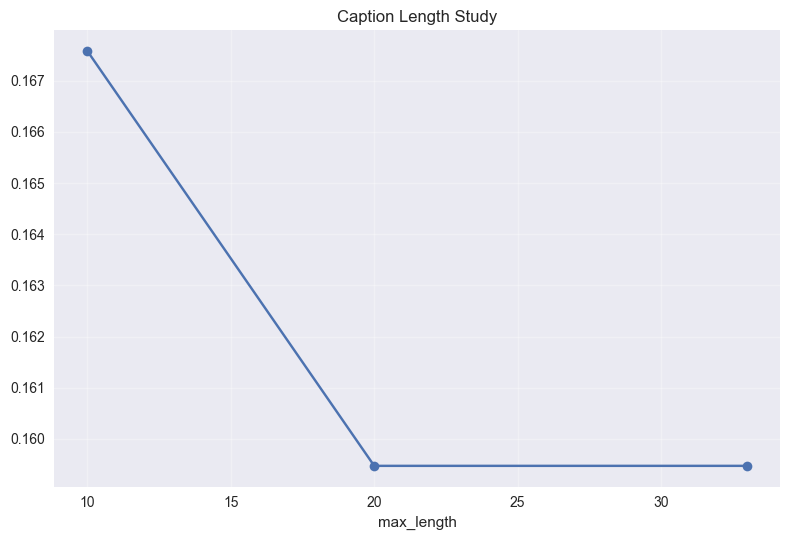

,bleu4,eval_images,hidden_size,implementation,max_length,meteor,recur_layers,recur_type,time_s
0,0.167577,1012,512,keras,10,0.339328,1,rnn,6.596178
1,0.159473,1012,512,keras,20,0.347779,1,rnn,17.829169
2,0.159473,1012,512,keras,33,0.347779,1,rnn,25.832090


In [64]:
length_path = TABLE_DIR / 'length_scores.json'
length_scores = load_json(length_path, []) if USE_EXISTING_SCORES and not REFRESH_LENGTH_STUDY else []

if len(length_scores) >= 3 and not REFRESH_LENGTH_STUDY:
    print('Pakai length study existing:', len(length_scores))
else:
    seen_lengths = {int(row['max_length']) for row in length_scores}
    all_candidates = list(best_by_type.values()) + scratch_scores
    best_overall = sorted(all_candidates, key=lambda row: (row.get('bleu4', 0), row.get('meteor', 0)), reverse=True)[0]
    print('best overall:', best_overall['implementation'], best_overall['recur_type'])
    for length in [10, 20, int(test_captions_all.shape[1] - 1)]:
        if length in seen_lengths:
            print('skip length', length)
            continue
        t0 = time.time()
        if best_overall['implementation'] == 'scratch':
            cfg = {
                'vocab_size': len(word_to_index), 'feature_dim': int(eval_features.shape[1]), 'embed_dim': 256,
                'hidden_size': int(best_overall['hidden_size']), 'recur_layers': int(best_overall['recur_layers']), 'recur_type': best_overall['recur_type']
            }
            decoder = build_decoder(cfg, artifact_path(best_overall['weight_path']))
            preds = decode_scratch(decoder, eval_features, length, SCRATCH_BATCH)
        else:
            model = tf.keras.models.load_model(artifact_path(best_overall['model_path']), safe_mode=False)
            preds = decode_keras(model, eval_features, length, KERAS_BATCH)
        elapsed = time.time() - t0
        row = {**score_predictions(preds, elapsed), 'max_length': int(length), 'implementation': best_overall['implementation'], 'recur_type': best_overall['recur_type']}
        length_scores.append(row)
        save_json(length_scores, length_path)

length_df = pd.DataFrame(length_scores)
length_df.to_csv(TABLE_DIR / 'length_scores.csv', index=False)
length_df.plot(x='max_length', y='bleu4', marker='o', legend=False, title='Caption Length Study')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'length_bleu4.png', dpi=150)
plt.show()
length_df


In [65]:
qual_path = TABLE_DIR / 'qualitative_examples.json'
qualitative = load_json(qual_path, []) if USE_EXISTING_SCORES and not REFRESH_QUALITATIVE else []

if len(qualitative) >= 10 and not REFRESH_QUALITATIVE:
    print('Pakai qualitative examples existing:', len(qualitative))
else:
    sample_count = min(100, len(eval_features))
    sample_features = eval_features[:sample_count]
    sample_refs = eval_refs[:sample_count]
    sample_ids = image_ids[:sample_count]
    preds_by_kind = {}
    for kind, best in best_by_type.items():
        model = tf.keras.models.load_model(artifact_path(best['model_path']), safe_mode=False)
        preds_by_kind[kind] = decode_keras(model, sample_features, int(test_captions_all.shape[1] - 1), KERAS_BATCH)
    avg_bleu = []
    for idx in range(sample_count):
        vals = [bleu4_score(sample_refs[idx], preds[idx]) for preds in preds_by_kind.values()]
        avg_bleu.append(float(np.mean(vals)))
    order = np.argsort(avg_bleu)
    selected = []
    for pool in np.array_split(order, 3):
        selected.extend(pool[:4].tolist())
    selected = selected[:10]
    qualitative = []
    for idx in selected:
        qualitative.append({
            'image_id': sample_ids[idx],
            'avg_bleu4': avg_bleu[idx],
            'ground_truth': [' '.join(ref) for ref in sample_refs[idx]],
            'rnn_prediction': ' '.join(preds_by_kind.get('rnn', [[]])[idx]) if 'rnn' in preds_by_kind else '',
            'lstm_prediction': ' '.join(preds_by_kind.get('lstm', [[]])[idx]) if 'lstm' in preds_by_kind else '',
        })
    save_json(qualitative, qual_path)

pd.DataFrame(qualitative).to_csv(TABLE_DIR / 'qualitative_examples.csv', index=False)
pd.DataFrame(qualitative)


Pakai qualitative examples existing: 10


,avg_bleu4,ground_truth_refs,image_id,lstm_prediction,rnn_prediction
0,0.017165,"[a small dog walks with men in the city, some ...",3353278454_2f3a4d0bbc.jpg,a man in a white shirt and a white hat is stan...,a man in a red jacket is standing in front of ...
1,0.023675,"[a group of people wait in similar attire, an ...",536537638_f5ee42410b.jpg,a man in a blue shirt and a white shirt is hol...,a woman in a black shirt and tie is smiling
2,0.027081,[a hiker walks on rocky ground at the base of ...,455611732_d65bf3e976.jpg,a man is riding a bike down a dirt road,a man is riding a horse on a racetrack
3,0.028634,"[a big dog is biting a smaller dog on the leg,...",2768972186_92787cd523.jpg,two dogs are playing with a toy,two dogs are playing in a field
4,0.058884,[a man bracing himself against the pull of a l...,2664103423_c539f61016.jpg,a man is skiing down a snowy hill,a man in a wetsuit is surfing on a boat
5,0.060389,"[two girls playing at a playground, two girls ...",3454988449_1de1ef4f20.jpg,a young boy jumps off a swing,a boy is jumping in a puddle
6,0.060535,[a boy and girl playing with buckets in a lawn...,2830869109_c4e403eae6.jpg,a girl in a pink shirt and a white shirt is pl...,a girl in a pink shirt is running on a beach
7,0.061323,[a boy in a white shirt and blue shirts is pla...,3163563871_cef3cf33ea.jpg,a man in a blue shirt is playing with a soccer...,a tennis player in a blue uniform is running t...
8,0.116951,[a man holding a sign with people walking arou...,251958970_fa6b423f23.jpg,a man in a blue shirt and a white shirt is sit...,a man in a leather jacket and tie earrings
9,0.119981,"[a man is wind sailing in the ocean, a man sta...",3037558954_20115165e3.jpg,a young boy is jumping off a slide into a pool,a man is surfing on a beach


In [66]:
raw_demo_path = TABLE_DIR / 'raw_caption_examples.json'
raw_rows = load_json(raw_demo_path, []) if USE_EXISTING_SCORES and not REFRESH_RAW_DEMO else []

if len(raw_rows) >= RAW_DEMO_COUNT and not REFRESH_RAW_DEMO:
    print('Pakai raw-image caption demo existing:', len(raw_rows))
elif not RAW_IMAGE_DIR.exists():
    print('Raw image directory belum tersedia:', RAW_IMAGE_DIR)
else:
    cached_weights = Path.home() / '.keras/models/inception_v3_weights_tf_dim_ordering_tf_kernels_notop.h5'
    weights_arg = str(cached_weights) if cached_weights.exists() else 'imagenet'
    encoder = tf.keras.applications.InceptionV3(include_top=False, weights=weights_arg, pooling='avg')
    encoder.trainable = False
    demo_ids = [row.get('image_id') for row in qualitative if row.get('image_id')][:RAW_DEMO_COUNT]
    if not demo_ids:
        demo_ids = image_ids[:RAW_DEMO_COUNT]
    decoders = {}
    for kind, best in best_by_type.items():
        cfg = {
            'vocab_size': len(word_to_index),
            'feature_dim': int(eval_features.shape[1]),
            'embed_dim': 256,
            'hidden_size': int(best['hidden_size']),
            'recur_layers': int(best['recur_layers']),
            'recur_type': kind,
        }
        decoders[kind] = build_decoder(cfg, artifact_path(best['weight_path']))

    raw_rows = []
    for image_id in demo_ids:
        image_path = RAW_IMAGE_DIR / image_id
        if not image_path.exists():
            continue
        image = image_loader(image_path, target_size=(299, 299))
        image = tf.keras.applications.inception_v3.preprocess_input(image[None, ...] * 255.0)
        feature = encoder.predict(image, verbose=0).astype('float32')
        row = {'image_id': image_id}
        for kind, decoder in decoders.items():
            pred = decode_scratch(decoder, feature, int(test_captions_all.shape[1] - 1), batch_size=1)[0]
            row[f'{kind}_scratch_caption'] = ' '.join(pred)
        raw_rows.append(row)
    save_json(raw_rows, raw_demo_path)

pd.DataFrame(raw_rows).to_csv(TABLE_DIR / 'raw_caption_examples.csv', index=False)
pd.DataFrame(raw_rows)


Pakai raw-image caption demo existing: 5


,image_id,rnn_scratch_caption,lstm_scratch_caption
0,3353278454_2f3a4d0bbc.jpg,a man in a leather jacket and tie is standing ...,a man in a white shirt is standing in front of...
1,536537638_f5ee42410b.jpg,a woman in a black shirt and tie is smiling,a man in a white shirt and a black hat is smiling
2,455611732_d65bf3e976.jpg,a man in a red jacket is riding a mountain,a man is riding a bike down a dirt road
3,2768972186_92787cd523.jpg,two dogs are playing in a field,two dogs are playing with a toy
4,2664103423_c539f61016.jpg,a man in a wetsuit is surfing,a man is riding a bike down a snowy hill
